# Billboard Boxing — EDA
**CIS 2450 Final Project**

**Research question:** Can Spotify audio features and metadata predict Billboard Hot 100 chart success?

This notebook explores the expanded dataset (62k songs, 1921–2024) to:
1. Understand the dataset structure, distributions, and quality
2. Compare audio feature distributions between hits and non-hits
3. Identify outliers and inform preprocessing decisions
4. Motivate feature and model choices for the modeling notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
COLORS = {'hit': '#E07B54', 'non_hit': '#5B8DB8'}

df = pd.read_csv('../data/processed/billboard_expanded_dataset.csv')
df['decade'] = (df['year'] // 10) * 10
df['label_str'] = df['label'].map({1: 'Billboard Hit', 0: 'Non-hit'})
df['is_imputed'] = df['features_imputed'].notna()

print(f'Dataset shape : {df.shape}')
print(f'Years covered : {int(df.year.min())} – {int(df.year.max())}')
print(f'Label balance : {df.label.value_counts().to_dict()}')
df.head(3)

Dataset shape : (62688, 27)
Years covered : 1921 – 2024
Label balance : {0: 31344, 1: 31344}


,label,year,title,artist,peak_rank,wks_on_chart,spotify_id,popularity,explicit,duration_ms,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,features_imputed,decade,label_str,is_imputed
0,0,1921,That's How You Spell Ireland,Morton Downey,NaN,NaN,3tEwdlwf8ZrxpksJorI5Tc,0.0,0.0,170240.0,...,0.0415,0.992,0.000001,0.105,0.173,86.493,NaN,1920,Non-hit,False
1,0,1921,Ne İçin Mahzun,Hanende İbrahim Efendi,NaN,NaN,38iWg7IcG1EXrxbibvq8Ox,0.0,0.0,155633.0,...,0.0356,0.995,0.935000,0.248,0.330,74.301,NaN,1920,Non-hit,False
2,0,1921,Pour Bien Reussir Dans La Chaussure,Maurice Chevalier,NaN,NaN,39ZYlUAoqyE05y7rsfeivo,0.0,0.0,169173.0,...,0.0551,0.995,0.000000,0.368,0.767,90.390,NaN,1920,Non-hit,False


## 1. Dataset Overview

We start with summary statistics and a check of missing values to understand
data quality before any analysis.

In [2]:
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

print('=== Label Distribution ===')
print(df['label'].value_counts())
print(f'Class balance: {df["label"].mean():.1%} positive (Billboard hits)')

print('\n=== Summary Statistics (audio features) ===')
print(df[AUDIO_FEATURES].describe().round(3).to_string())

print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)
print('\nNote: peak_rank and wks_on_chart are NaN for non-hits (label=0) by design.')
print(f'features_imputed NaN means real audio data ({(~df.is_imputed).sum():,} rows).')

=== Label Distribution ===
label
0    31344
1    31344
Name: count, dtype: int64
Class balance: 50.0% positive (Billboard hits)

=== Summary Statistics (audio features) ===
       danceability     energy   loudness  speechiness  acousticness  instrumentalness   liveness    valence      tempo
count     62688.000  62688.000  62688.000    62688.000     62688.000         62688.000  62688.000  62688.000  62688.000
mean          0.558      0.530    -10.371        0.077         0.416             0.095      0.182      0.554    117.700
std           0.150      0.230      4.761        0.119         0.340             0.248      0.148      0.224     25.940
min           0.000      0.000    -55.000        0.000         0.000             0.000      0.000      0.000      0.000
25%           0.492      0.360    -12.348        0.037         0.106             0.000      0.108      0.421    102.621
50%           0.567      0.545    -10.163        0.041         0.338             0.000      0.130      0.58

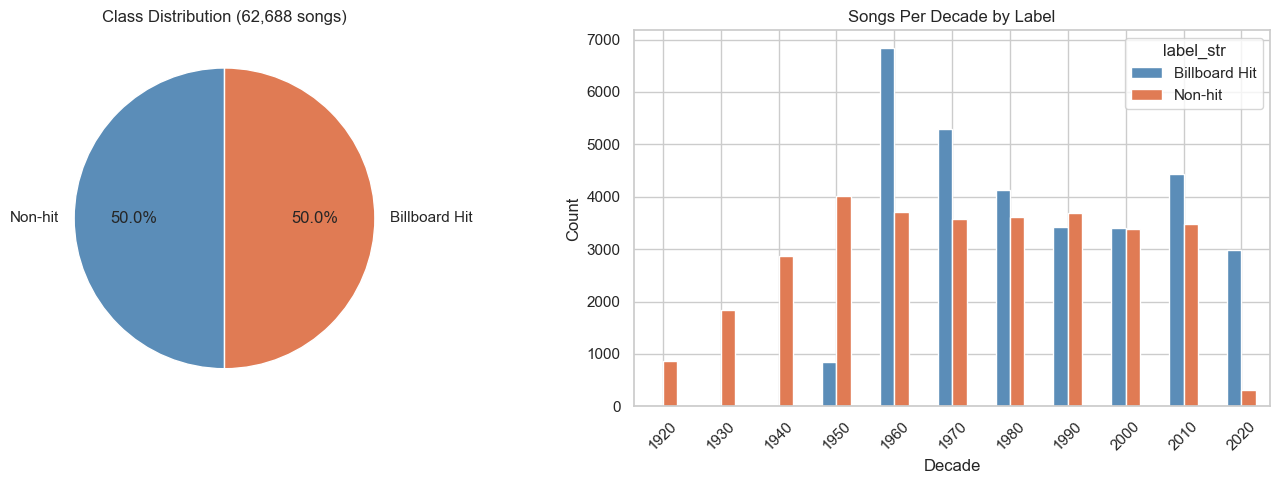

In [3]:
# Label distribution + songs per decade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['label'].value_counts()
axes[0].pie(
    counts,
    labels=['Non-hit', 'Billboard Hit'],
    autopct='%1.1f%%',
    colors=[COLORS['non_hit'], COLORS['hit']],
    startangle=90,
)
axes[0].set_title('Class Distribution (62,688 songs)')

decade_label = df.groupby(['decade', 'label_str']).size().unstack(fill_value=0)
decade_label.plot(kind='bar', ax=axes[1], color=[COLORS['non_hit'], COLORS['hit']])
axes[1].set_title('Songs Per Decade by Label')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Audio Feature Distributions: Hits vs Non-Hits

We compare the distribution of each audio feature between Billboard hits and non-hits.
Features with clearly separated distributions will be more useful predictors.

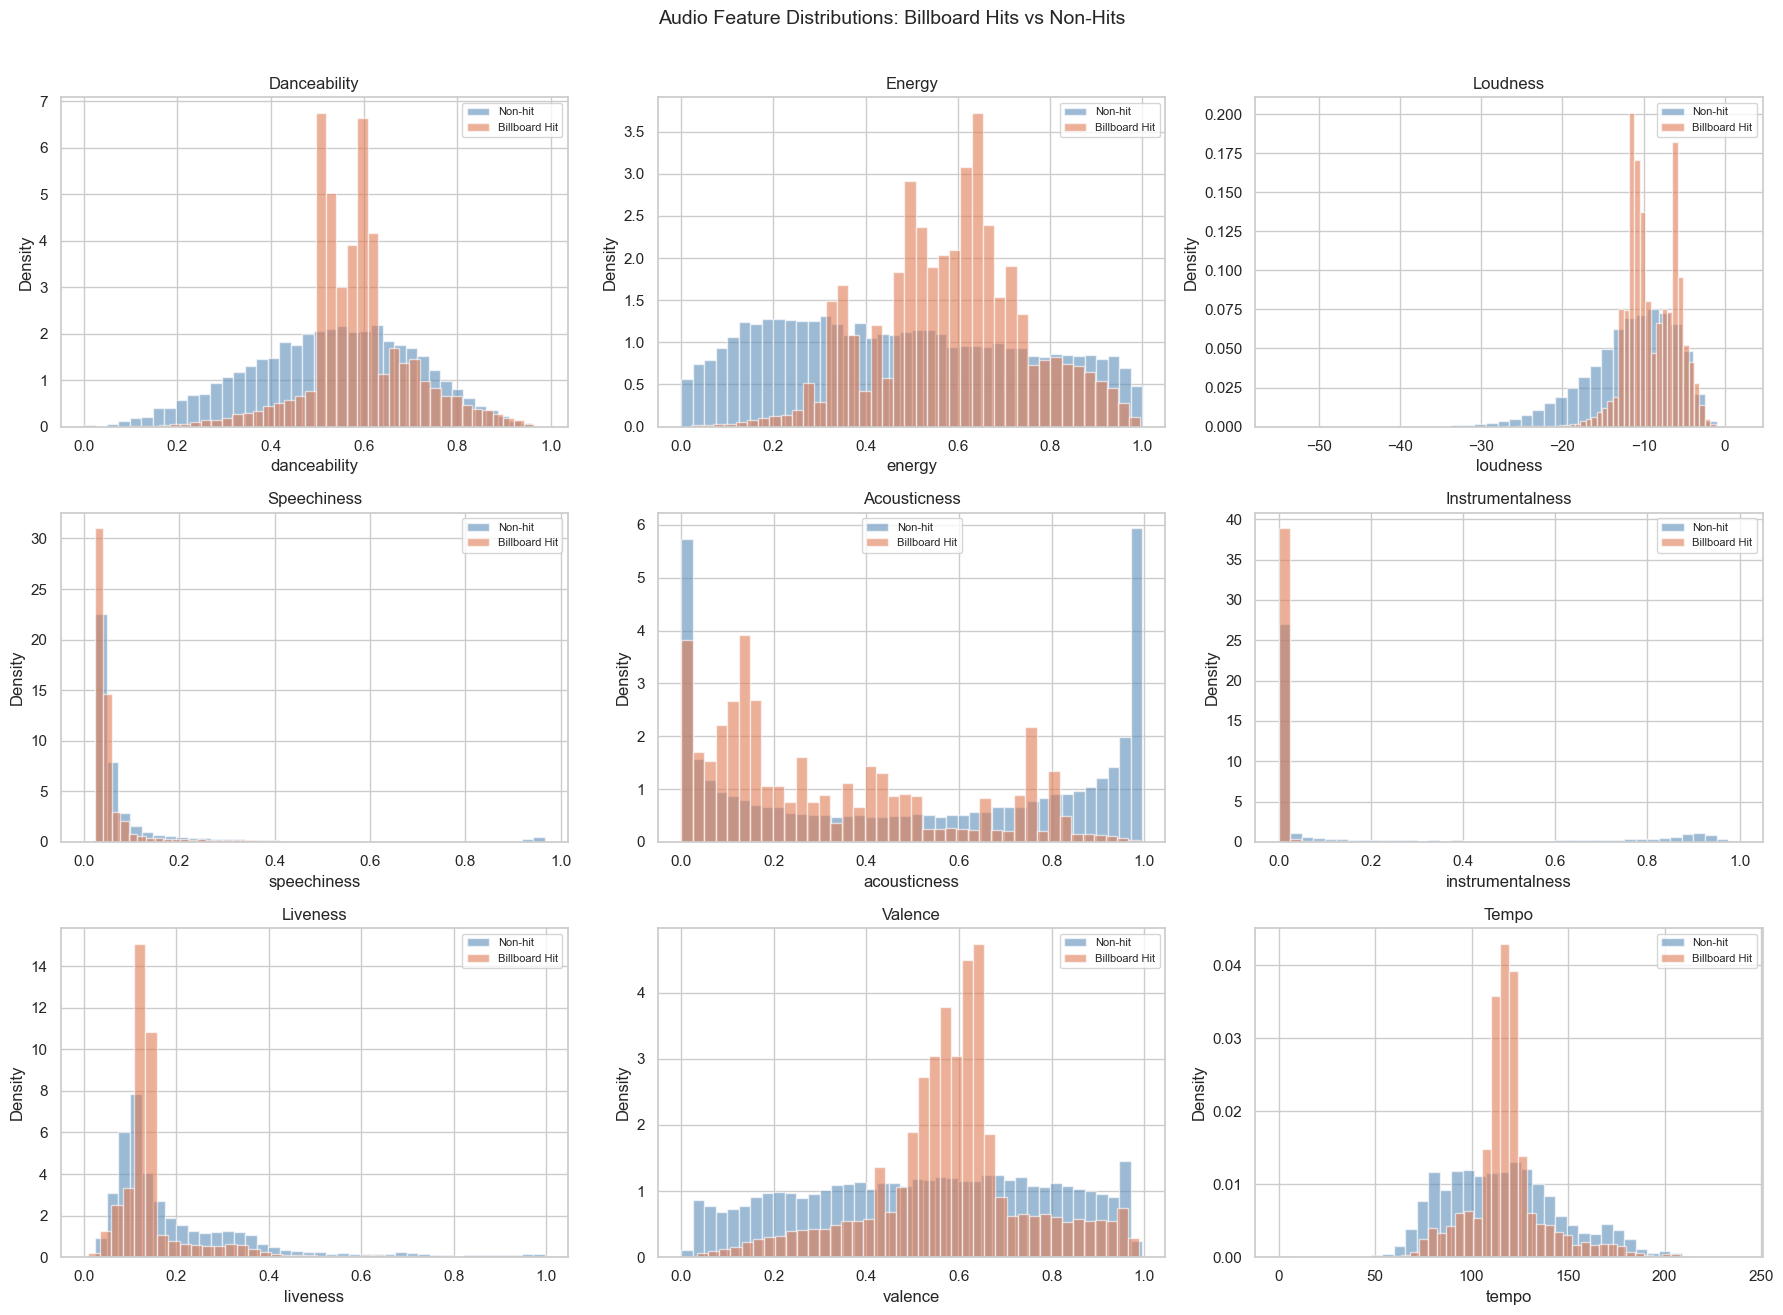

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for ax, feat in zip(axes, AUDIO_FEATURES):
    hits     = df[df['label'] == 1][feat].dropna()
    non_hits = df[df['label'] == 0][feat].dropna()
    ax.hist(non_hits, bins=40, alpha=0.6, color=COLORS['non_hit'], label='Non-hit', density=True)
    ax.hist(hits,     bins=40, alpha=0.6, color=COLORS['hit'],     label='Billboard Hit', density=True)
    ax.set_title(feat.capitalize())
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Audio Feature Distributions: Billboard Hits vs Non-Hits', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/audio_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_14138/364844479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_14138/364844479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_14138/364844479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_14138/364844479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_14138/364844479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_14138/364844479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_14138/364844479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_14138/364844479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

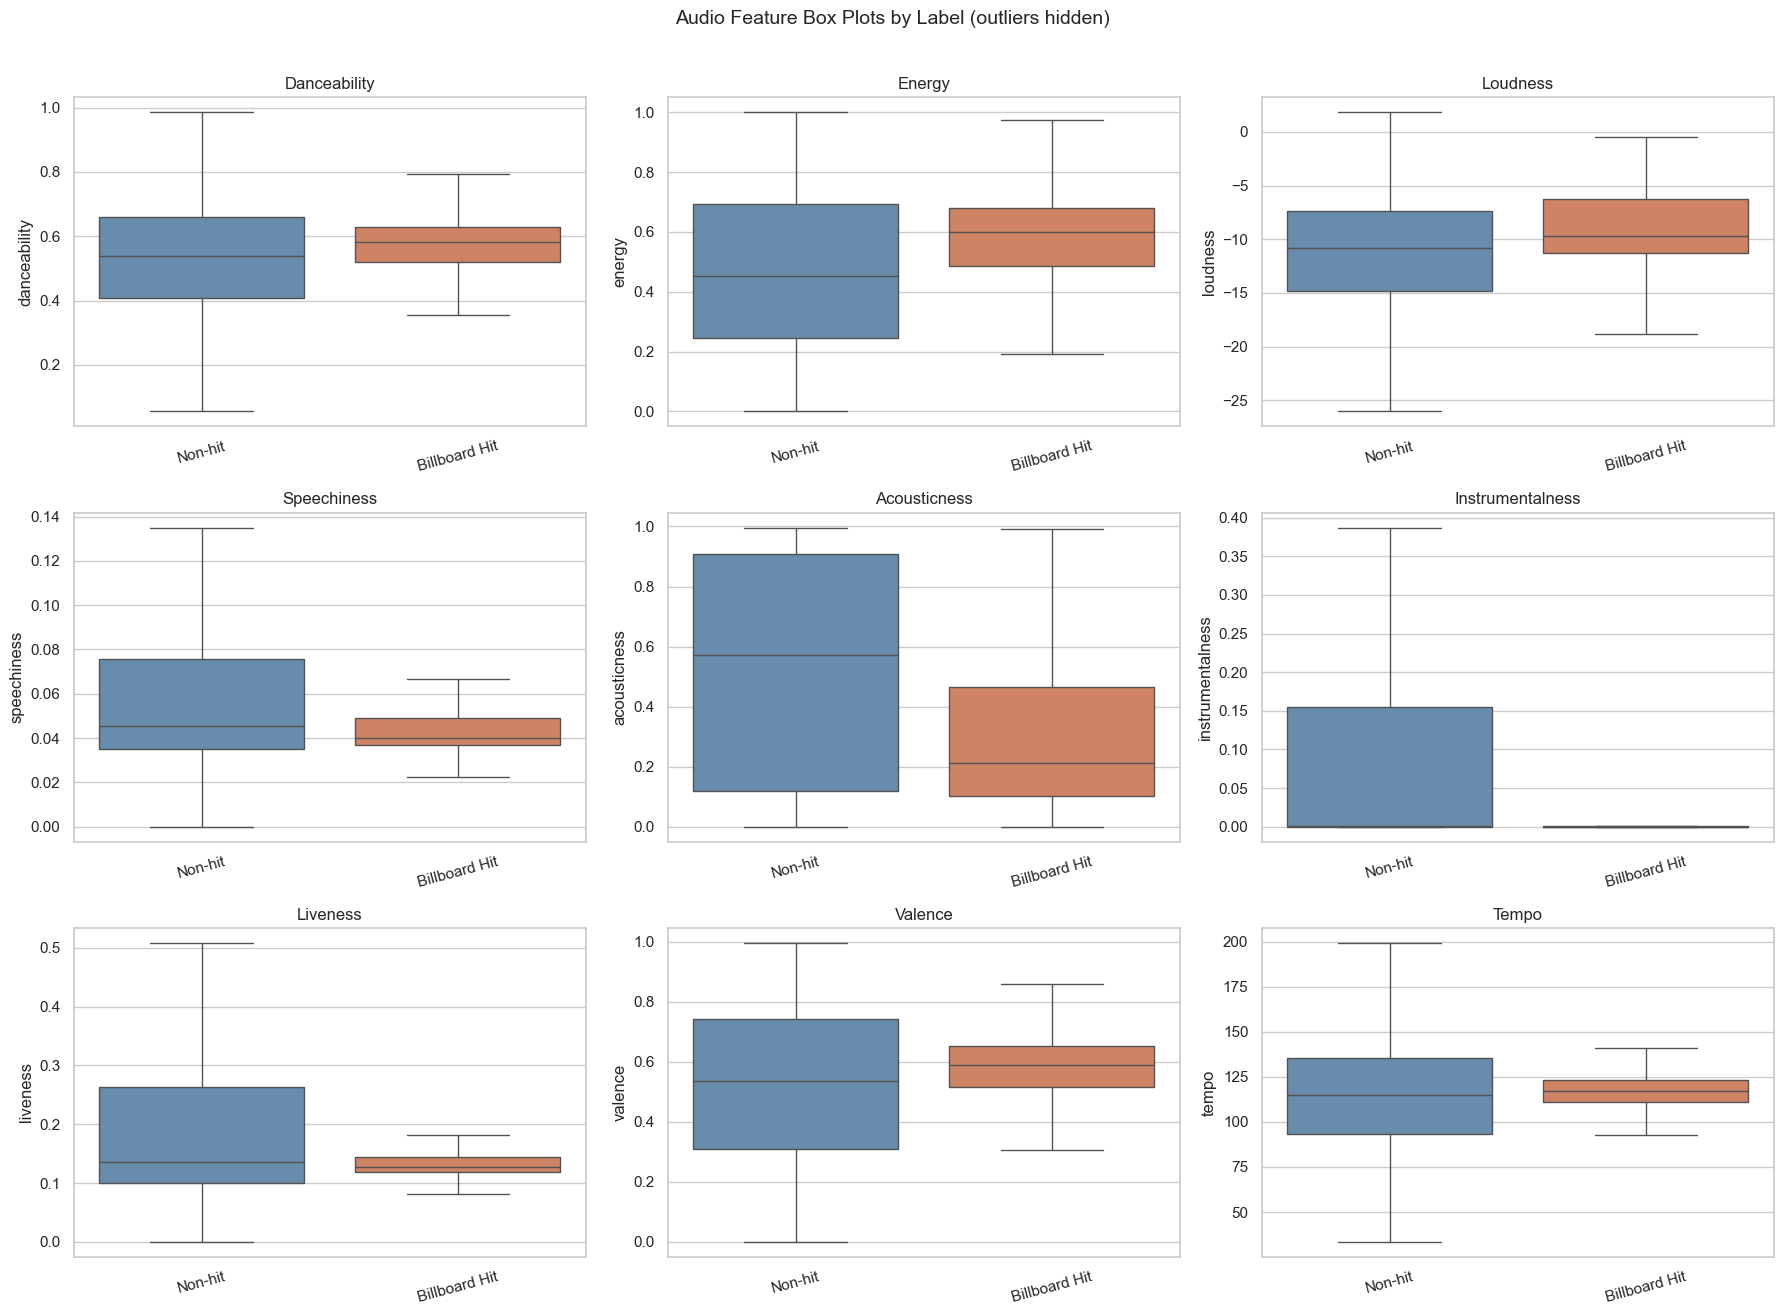

In [5]:
# Box plots for cleaner comparison
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for ax, feat in zip(axes, AUDIO_FEATURES):
    sns.boxplot(
        data=df, x='label_str', y=feat, ax=ax,
        palette={'Billboard Hit': COLORS['hit'], 'Non-hit': COLORS['non_hit']},
        showfliers=False,
    )
    ax.set_title(feat.capitalize())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Audio Feature Box Plots by Label (outliers hidden)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/audio_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Hypothesis Testing

We use two-sample t-tests to formally check whether the mean of each audio feature
differs significantly between hits and non-hits. A low p-value (< 0.05) means the
difference is statistically significant and the feature likely carries predictive signal.

In [6]:
hits_df     = df[df['label'] == 1]
non_hits_df = df[df['label'] == 0]

test_results = []
for feat in AUDIO_FEATURES:
    h  = hits_df[feat].dropna()
    nh = non_hits_df[feat].dropna()
    t_stat, p_val = stats.ttest_ind(h, nh, equal_var=False)
    test_results.append({
        'Feature':        feat,
        'Mean (Hits)':    h.mean(),
        'Mean (Non-hits)': nh.mean(),
        'Difference':     h.mean() - nh.mean(),
        't-statistic':    t_stat,
        'p-value':        p_val,
        'Significant':    'Yes' if p_val < 0.05 else 'No',
    })

ttest_df = pd.DataFrame(test_results).sort_values('p-value')
print('Two-sample t-test: Hits vs Non-Hits for each audio feature')
print(ttest_df.round(4).to_string(index=False))

Two-sample t-test: Hits vs Non-Hits for each audio feature
         Feature  Mean (Hits)  Mean (Non-hits)  Difference  t-statistic  p-value Significant
    danceability       0.5851           0.5304      0.0547      46.3971      0.0         Yes
          energy       0.5871           0.4725      0.1145      64.3721      0.0         Yes
        loudness      -9.0506         -11.6911      2.6405      72.2681      0.0         Yes
     speechiness       0.0582           0.0962     -0.0380     -40.3628      0.0         Yes
    acousticness       0.3084           0.5233     -0.2149     -83.2799      0.0         Yes
instrumentalness       0.0112           0.1794     -0.1681     -90.0476      0.0         Yes
        liveness       0.1559           0.2076     -0.0517     -44.4386      0.0         Yes
         valence       0.5830           0.5250      0.0580      32.7400      0.0         Yes
           tempo     118.4896         116.9107      1.5789       7.6233      0.0         Yes


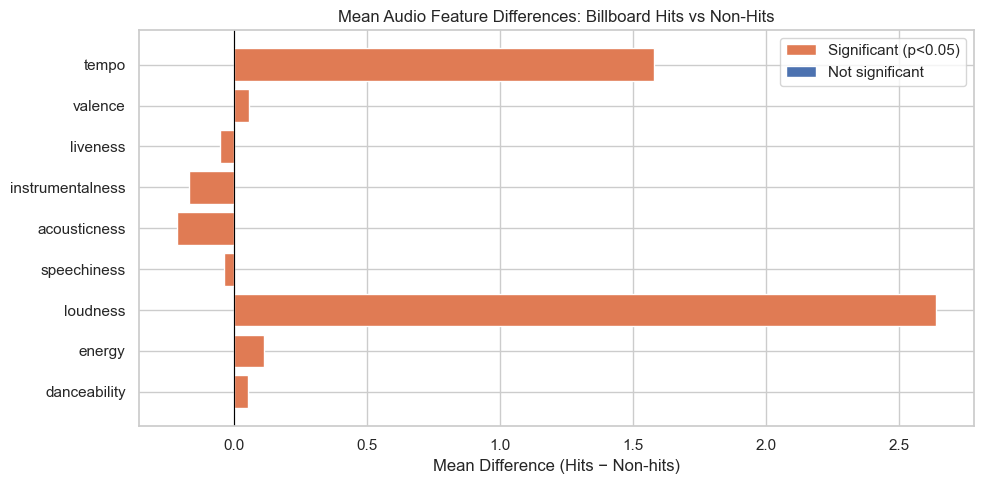

In [7]:
# Visualise mean differences
sig = ttest_df[ttest_df['Significant'] == 'Yes']
insig = ttest_df[ttest_df['Significant'] == 'No']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sig['Feature'],   sig['Difference'],   color=COLORS['hit'],     label='Significant (p<0.05)')
ax.barh(insig['Feature'], insig['Difference'], color='lightgray', label='Not significant')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean Difference (Hits − Non-hits)')
ax.set_title('Mean Audio Feature Differences: Billboard Hits vs Non-Hits')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/mean_differences.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Temporal Trends

Music tastes change over time. We examine how key audio features have shifted
across decades for hits vs non-hits — this also validates that our dataset spans
era-level variation.

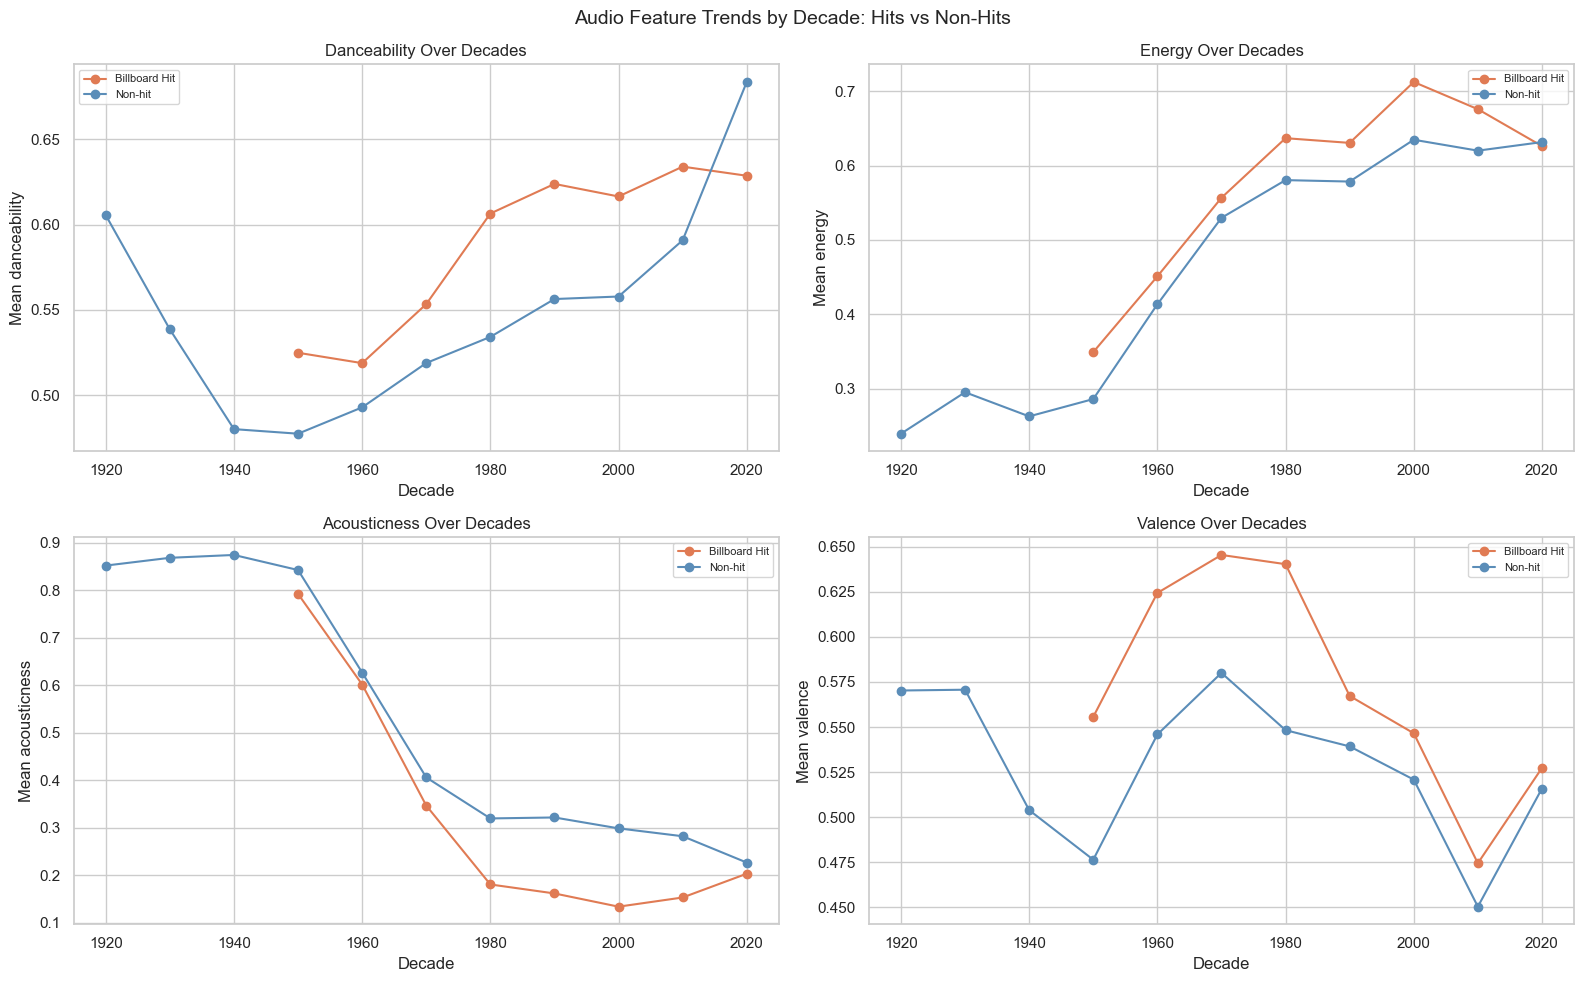

In [8]:
trend_features = ['danceability', 'energy', 'acousticness', 'valence']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, feat in zip(axes, trend_features):
    for label_val, label_name, color in [
        (1, 'Billboard Hit', COLORS['hit']),
        (0, 'Non-hit',       COLORS['non_hit']),
    ]:
        trend = (
            df[df['label'] == label_val]
            .groupby('decade')[feat]
            .mean()
        )
        ax.plot(trend.index, trend.values, marker='o', label=label_name, color=color)
    ax.set_title(f'{feat.capitalize()} Over Decades')
    ax.set_xlabel('Decade')
    ax.set_ylabel(f'Mean {feat}')
    ax.legend(fontsize=8)

plt.suptitle('Audio Feature Trends by Decade: Hits vs Non-Hits', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/feature_trends_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Outlier Detection & Handling

We use the IQR method to identify extreme outliers in each audio feature.
Outliers in audio features may represent data errors or genuinely unusual songs.
We report them here but **do not remove** them — tree-based models (Random Forest,
XGBoost) are robust to outliers, so removal is not necessary.

In [9]:
outlier_summary = []
for feat in AUDIO_FEATURES:
    col = df[feat].dropna()
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((col < Q1 - 3 * IQR) | (col > Q3 + 3 * IQR)).sum()
    outlier_summary.append({'Feature': feat, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'Outliers (3×IQR)': n_out, '% of rows': f'{n_out/len(df)*100:.2f}%'})

out_df = pd.DataFrame(outlier_summary)
print('Outlier summary (3×IQR rule):')
print(out_df.round(3).to_string(index=False))
print('\nDecision: retain outliers — tree-based models are robust to extreme values.')

Outlier summary (3×IQR rule):
         Feature      Q1      Q3    IQR  Outliers (3×IQR) % of rows
    danceability   0.492   0.645  0.153                32     0.05%
          energy   0.360   0.687  0.328                 0     0.00%
        loudness -12.348  -6.715  5.633               293     0.47%
     speechiness   0.037   0.061  0.024              6451    10.29%
    acousticness   0.106   0.759  0.653                 0     0.00%
instrumentalness   0.000   0.002  0.002             13126    20.94%
        liveness   0.108   0.191  0.083              3618     5.77%
         valence   0.421   0.684  0.263                 0     0.00%
           tempo 102.621 128.022 25.401               203     0.32%

Decision: retain outliers — tree-based models are robust to extreme values.


## 6. Feature Correlation

Highly correlated features can cause multicollinearity in Logistic Regression
and add redundancy to tree models. We visualise the correlation matrix and
flag any pair with |r| > 0.7.

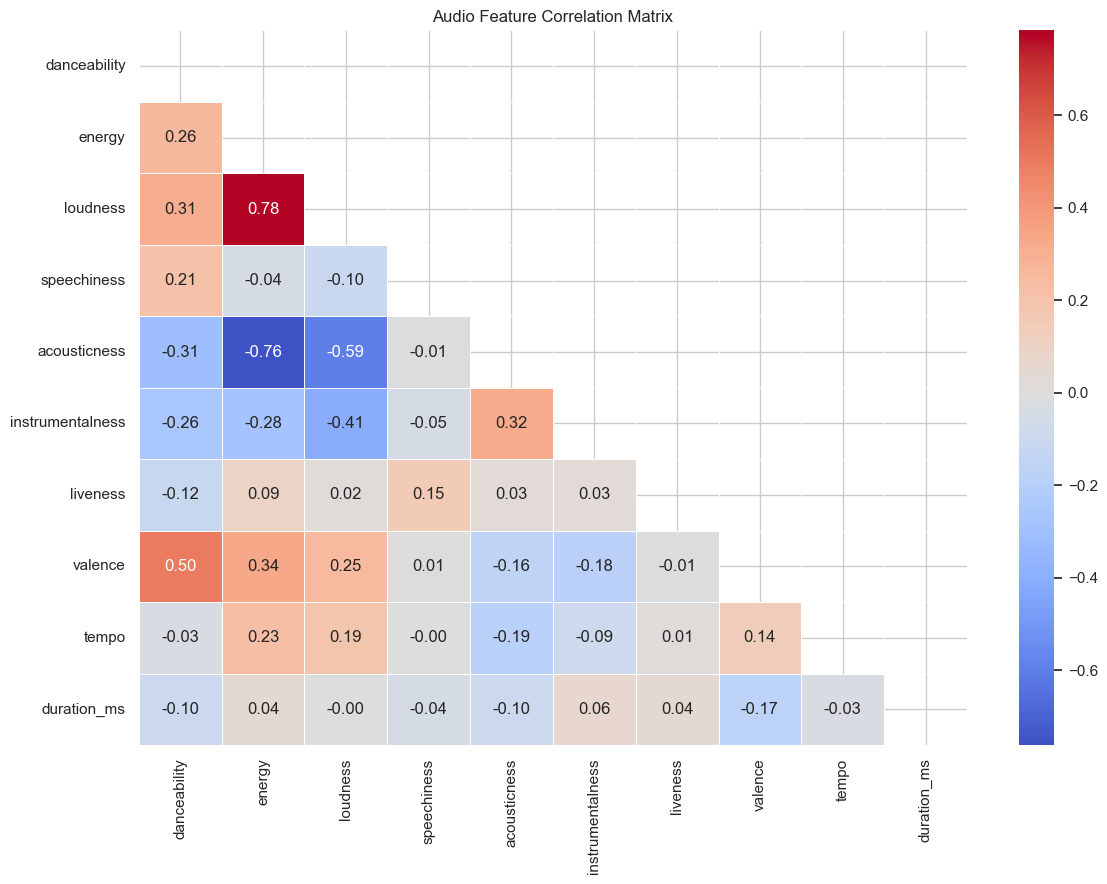

Pairs with |r| > 0.7: [('energy', 'loudness', np.float64(0.784)), ('energy', 'acousticness', np.float64(-0.761))]


In [10]:
corr = df[AUDIO_FEATURES + ['duration_ms']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Audio Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap_eda.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr = [(c1, c2, round(corr.loc[c1,c2], 3))
             for i, c1 in enumerate(corr.columns)
             for c2 in corr.columns[i+1:]
             if abs(corr.loc[c1,c2]) > 0.7]
if high_corr:
    print('Pairs with |r| > 0.7:', high_corr)
else:
    print('No pairs with |r| > 0.7 — no features dropped on correlation grounds.')

## 7. Duration & Explicit Content

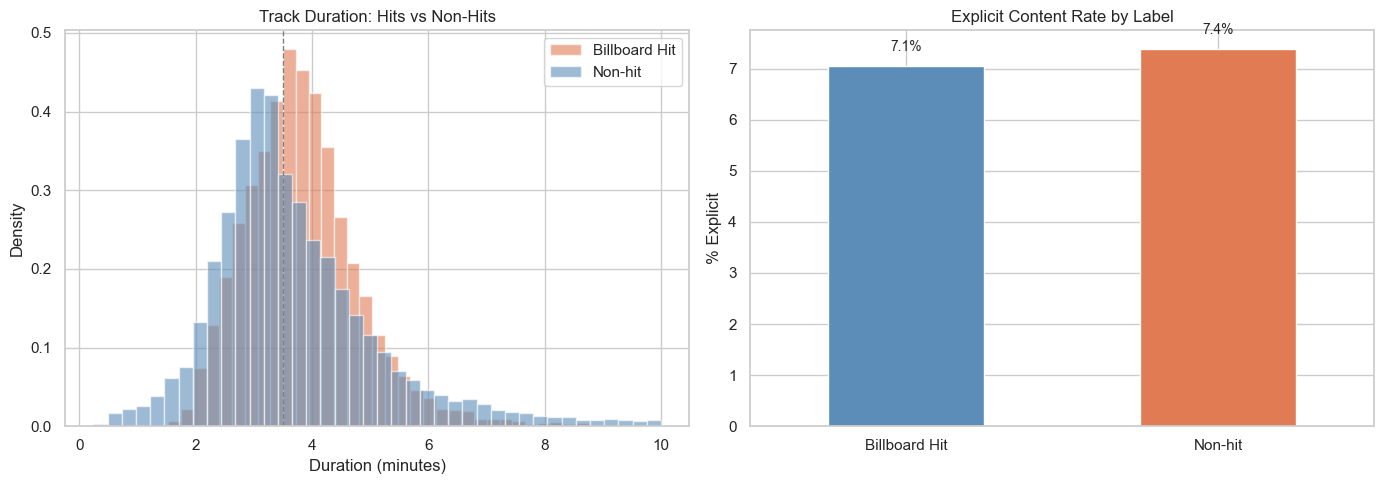

Mean duration — Hits: 3.86 min  | Non-hits: 3.84 min


In [11]:
df['duration_min'] = df['duration_ms'] / 60000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration distribution
for label_val, name, color in [(1,'Billboard Hit',COLORS['hit']),(0,'Non-hit',COLORS['non_hit'])]:
    data = df[(df['label']==label_val) & (df['duration_min'] < 10)]['duration_min']
    axes[0].hist(data, bins=40, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title('Track Duration: Hits vs Non-Hits')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(3.5, color='gray', linestyle='--', linewidth=1, label='3.5 min')

# Explicit content
explicit_df = df.copy()
explicit_df['explicit_flag'] = explicit_df['explicit'].fillna(0).astype(int)
exp_pct = explicit_df.groupby('label_str')['explicit_flag'].mean() * 100
exp_pct.plot(kind='bar', ax=axes[1], color=[COLORS['non_hit'], COLORS['hit']], rot=0)
axes[1].set_title('Explicit Content Rate by Label')
axes[1].set_xlabel('')
axes[1].set_ylabel('% Explicit')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/duration_explicit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean duration — Hits: {df[df.label==1]['duration_min'].mean():.2f} min  "
      f"| Non-hits: {df[df.label==0]['duration_min'].mean():.2f} min")

## 8. Peak Chart Rank Distribution (Hits only)

For Billboard hits, we examine the peak rank distribution. This informs whether
a multi-class (Top 10 / Top 11–50 / Top 51–100) framing is feasible.

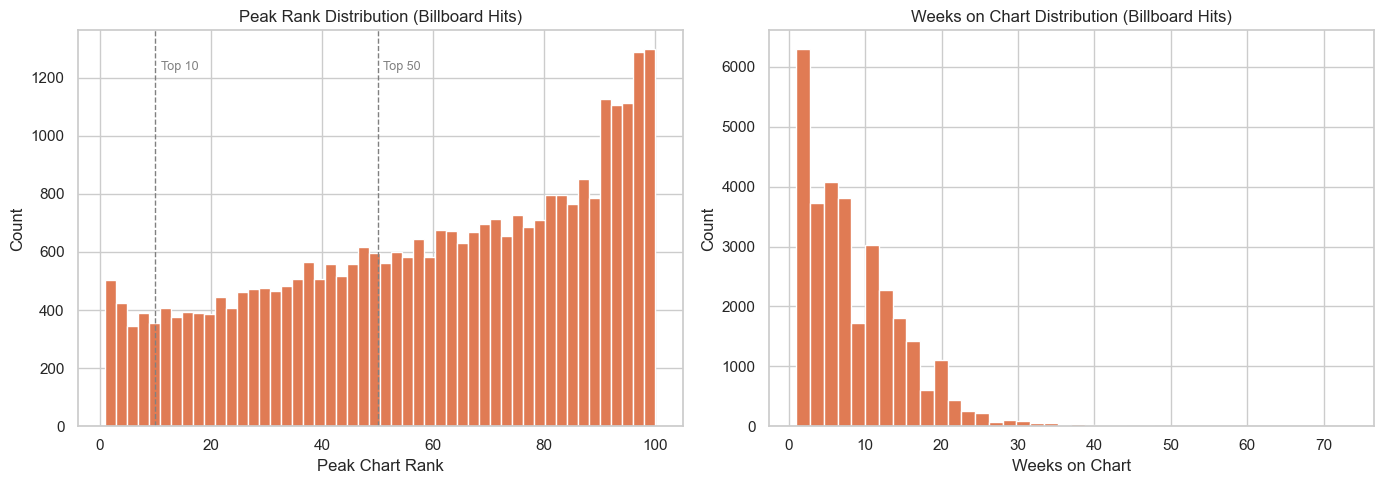

Hit distribution by rank bucket:
rank_bucket
Top 10         2021
Top 11–50      9587
Top 51–100    19736
Name: count, dtype: int64


In [12]:
hits_only = df[(df['label'] == 1) & df['peak_rank'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hits_only['peak_rank'], bins=50, color=COLORS['hit'], edgecolor='white')
axes[0].set_title('Peak Rank Distribution (Billboard Hits)')
axes[0].set_xlabel('Peak Chart Rank')
axes[0].set_ylabel('Count')
for cutoff, label in [(10, 'Top 10'), (50, 'Top 50')]:
    axes[0].axvline(cutoff, color='gray', linestyle='--', linewidth=1)
    axes[0].text(cutoff+1, axes[0].get_ylim()[1]*0.9, label, fontsize=9, color='gray')

# Weeks on chart
axes[1].hist(hits_only['wks_on_chart'].dropna(), bins=40, color=COLORS['hit'], edgecolor='white')
axes[1].set_title('Weeks on Chart Distribution (Billboard Hits)')
axes[1].set_xlabel('Weeks on Chart')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/figures/peak_rank_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Bucket breakdown
hits_only['rank_bucket'] = pd.cut(hits_only['peak_rank'],
                                   bins=[0,10,50,100],
                                   labels=['Top 10','Top 11–50','Top 51–100'])
print('Hit distribution by rank bucket:')
print(hits_only['rank_bucket'].value_counts().sort_index())

## 9. EDA Summary & Modeling Implications

### Key findings

**1. Feature distributions differ between hits and non-hits**  
Billboard hits tend to have higher danceability, energy, and loudness than non-hits,
while non-hits skew more acoustic and instrumental. The t-tests confirm most of
these differences are statistically significant (p < 0.05), validating that audio
features carry genuine predictive signal.

**2. Temporal drift is real**  
Acousticness has declined sharply since the 1950s while energy has risen — hits
and non-hits track these trends together, but hits consistently sit at the
"more commercial" end of each era's spectrum. This motivates including `decade`
as an engineered feature in modeling.

**3. No severe multicollinearity**  
No feature pair exceeds |r| = 0.7, so no features need to be dropped on
correlation grounds. Logistic Regression should be stable without further removal.

**4. Outliers exist but are benign**  
A small fraction of songs have extreme values (very long duration, very high
instrumentalness). These are likely classical or ambient recordings in the
Kaggle non-hit pool. Tree-based models handle these natively; we retain them.

**5. Multi-class framing is feasible**  
The peak rank distribution is roughly uniform across Top 10 / 11–50 / 51–100
buckets, making a 3-class version of the task possible as a future extension.

### Preprocessing decisions motivated by EDA
- **Scale features** for Logistic Regression (StandardScaler inside Pipeline)
- **Impute remaining nulls** with training-set median (SimpleImputer inside Pipeline)
- **Engineer `decade`** to capture era-level trend
- **Exclude `popularity`** — reflects current streams, not release-era success (label leakage risk)
- **Retain outliers** — no removal needed for tree models